In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [4]:
median_price = df['MedHouseVal'].median()
df['PriceCategory'] = (df['MedHouseVal'] > median_price).astype(int)  # 1 = expensive, 0 = affordable

X = df.drop(columns=['MedHouseVal', 'PriceCategory'])
y = df['PriceCategory']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [9]:
print("Intercept:", model.intercept_[0])
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)
print("\nCoefficients (standardized):\n", coef_df.to_string(index=False))

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Intercept: 0.031935255507978766

Coefficients (standardized):
    Feature  Coefficient
  Latitude    -3.589131
 Longitude    -3.384452
  AveOccup    -2.653431
    MedInc     2.479615
 AveBedrms     0.923242
  AveRooms    -0.777231
  HouseAge     0.258544
Population     0.054164

Accuracy: 0.8313953488372093
Precision: 0.8339032730825598
Recall: 0.827435773145904
F1 Score: 0.8306569343065694
ROC-AUC: 0.9133693027972382

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.83      2065
           1       0.83      0.83      0.83      2063

    accuracy                           0.83      4128
   macro avg       0.83      0.83      0.83      4128
weighted avg       0.83      0.83      0.83      4128



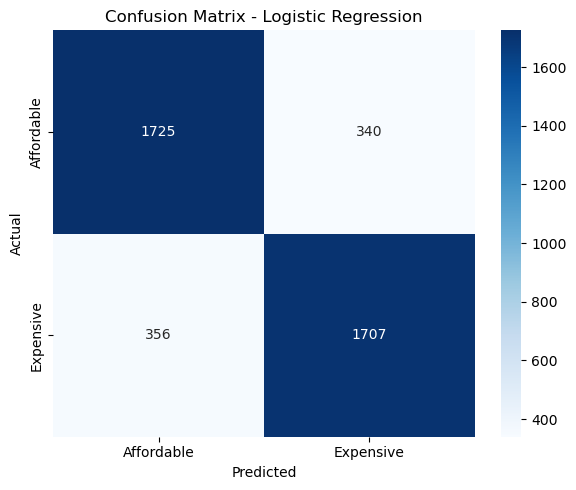

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Affordable', 'Expensive'],
            yticklabels=['Affordable', 'Expensive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

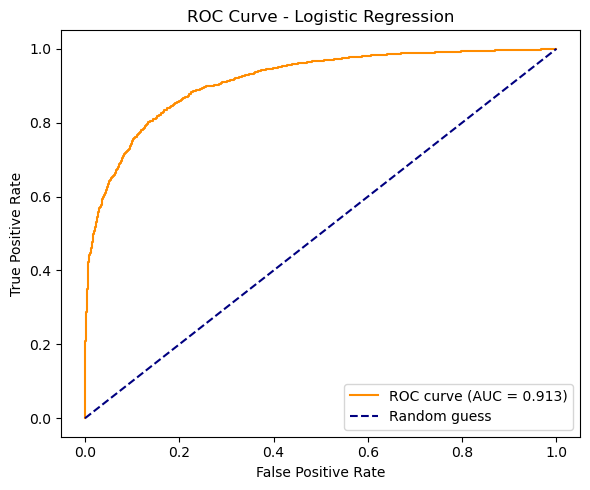

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()